In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

import joblib
import warnings
warnings.filterwarnings('ignore')


In [176]:
df = pd.read_csv('BankChurners.csv')
print('Shape of the dataset:', df.shape)
print('First 5 rows of the dataset:')
print(df.head())

Shape of the dataset: (10127, 23)
First 5 rows of the dataset:
   CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0  768805383  Existing Customer            45      M                3   
1  818770008  Existing Customer            49      F                5   
2  713982108  Existing Customer            51      M                3   
3  769911858  Existing Customer            40      F                4   
4  709106358  Existing Customer            40      M                3   

  Education_Level Marital_Status Income_Category Card_Category  \
0     High School        Married     $60K - $80K          Blue   
1        Graduate         Single  Less than $40K          Blue   
2        Graduate        Married    $80K - $120K          Blue   
3     High School        Unknown  Less than $40K          Blue   
4      Uneducated        Married     $60K - $80K          Blue   

   Months_on_book  ...  Credit_Limit  Total_Revolving_Bal  Avg_Open_To_Buy  \
0              39  ... 

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

# Dropping Last two cols of the dataset

In [178]:
df = df.drop(columns=[
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"
])

In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [180]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [181]:
# Chesking for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64


In [182]:
# target variable distribution
print('Attrition_Flag value counts:  ')
print(df['Attrition_Flag'].value_counts())
print('Attrition_Flag value counts (percentage):  ')
print(df['Attrition_Flag'].value_counts(normalize=True) * 100)

Attrition_Flag value counts:  
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64
Attrition_Flag value counts (percentage):  
Attrition_Flag
Existing Customer    83.934038
Attrited Customer    16.065962
Name: proportion, dtype: float64


Numeric columns: Index(['CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')


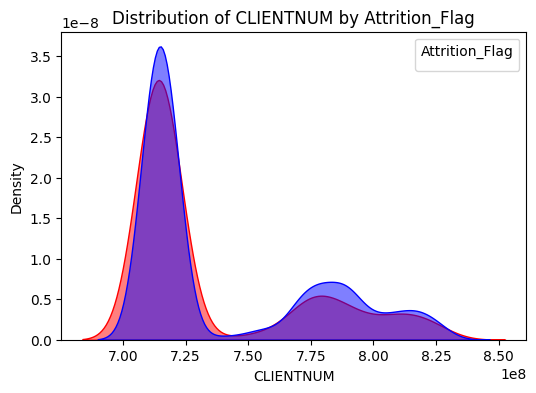

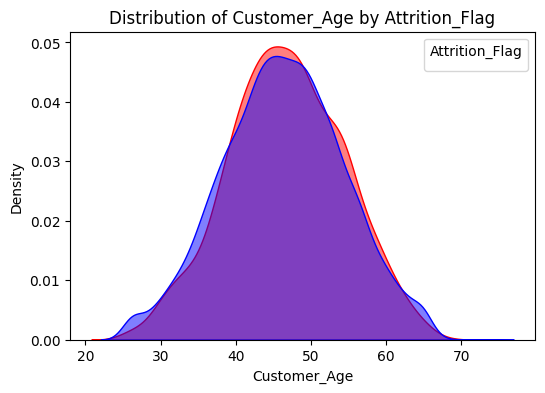

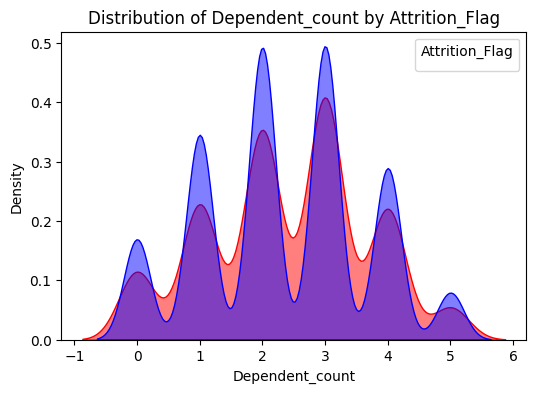

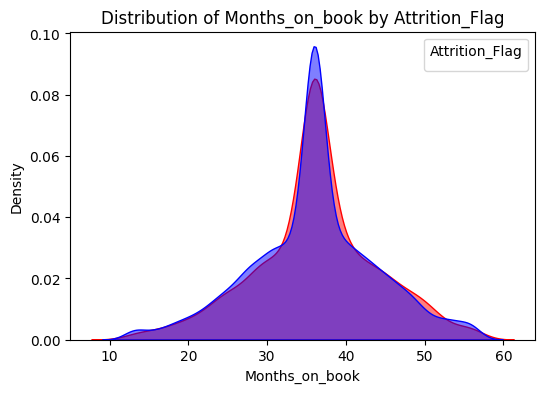

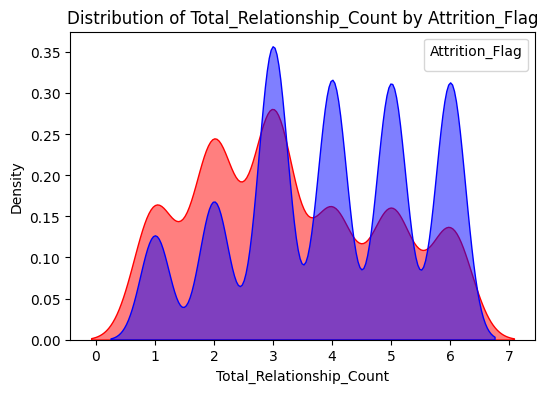

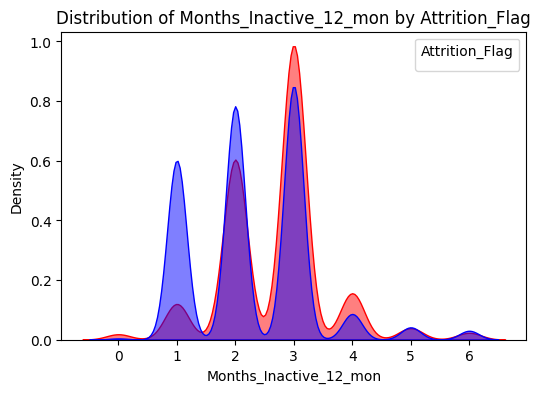

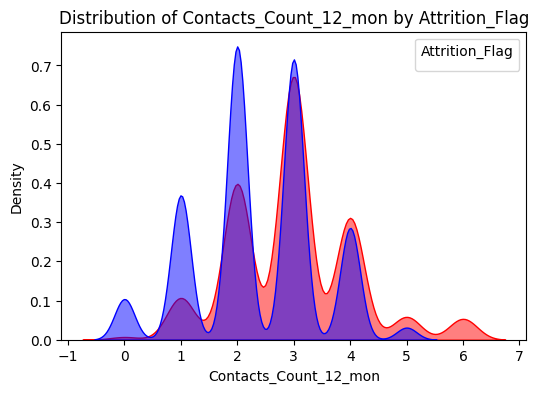

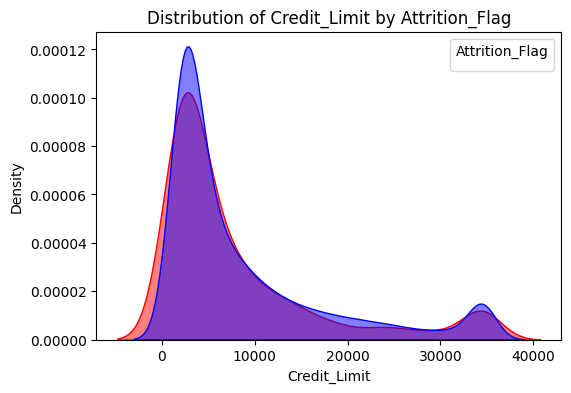

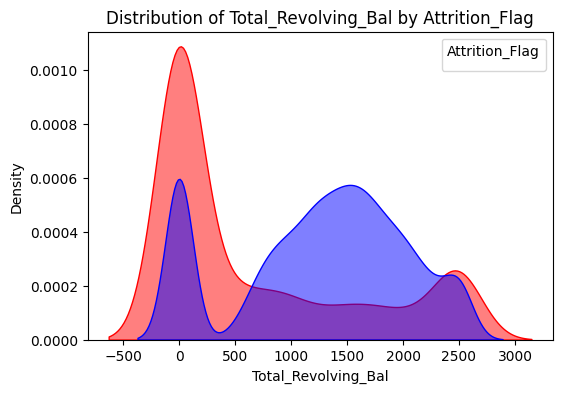

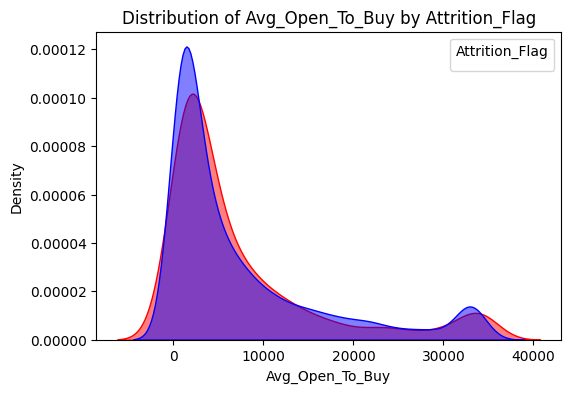

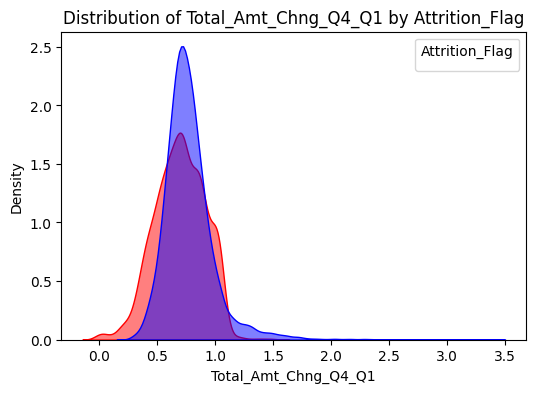

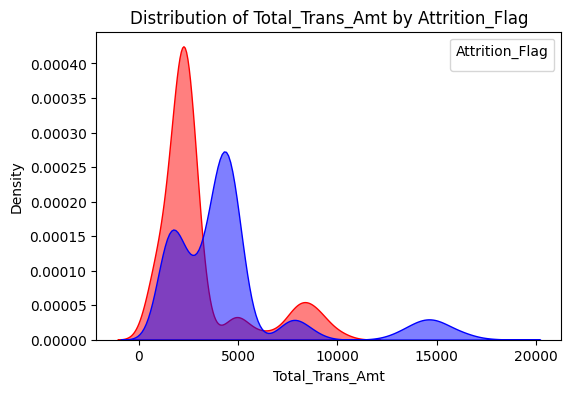

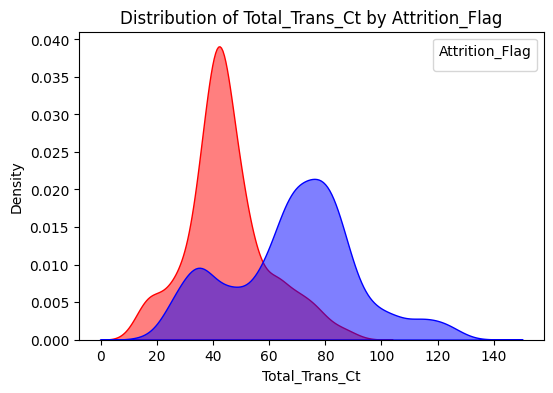

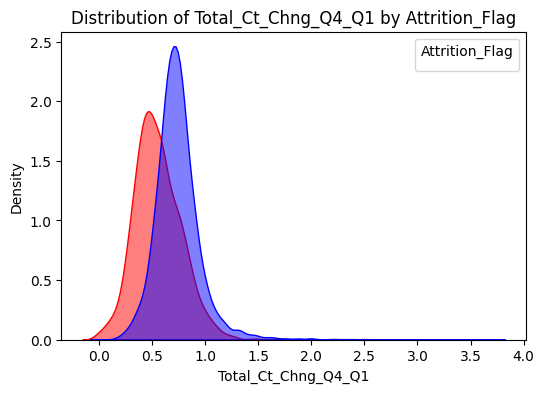

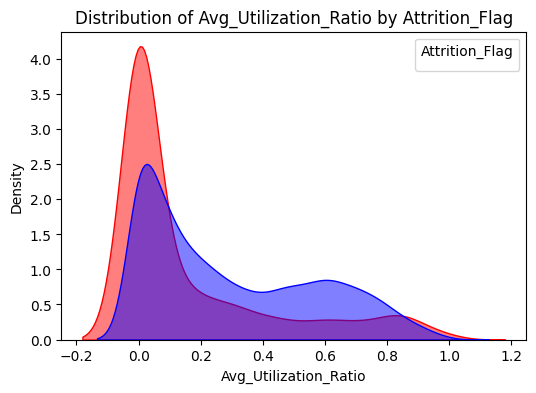

In [183]:
neumeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeric columns:", neumeric_cols)
for col in neumeric_cols:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data = df, x = col, hue=df['Attrition_Flag'], fill=True ,common_norm=False,alpha=0.5,palette={'Existing Customer': 'blue', 'Attrited Customer': 'red'})
    plt.title(f'Distribution of {col} by Attrition_Flag')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend(title='Attrition_Flag')
    plt.show()

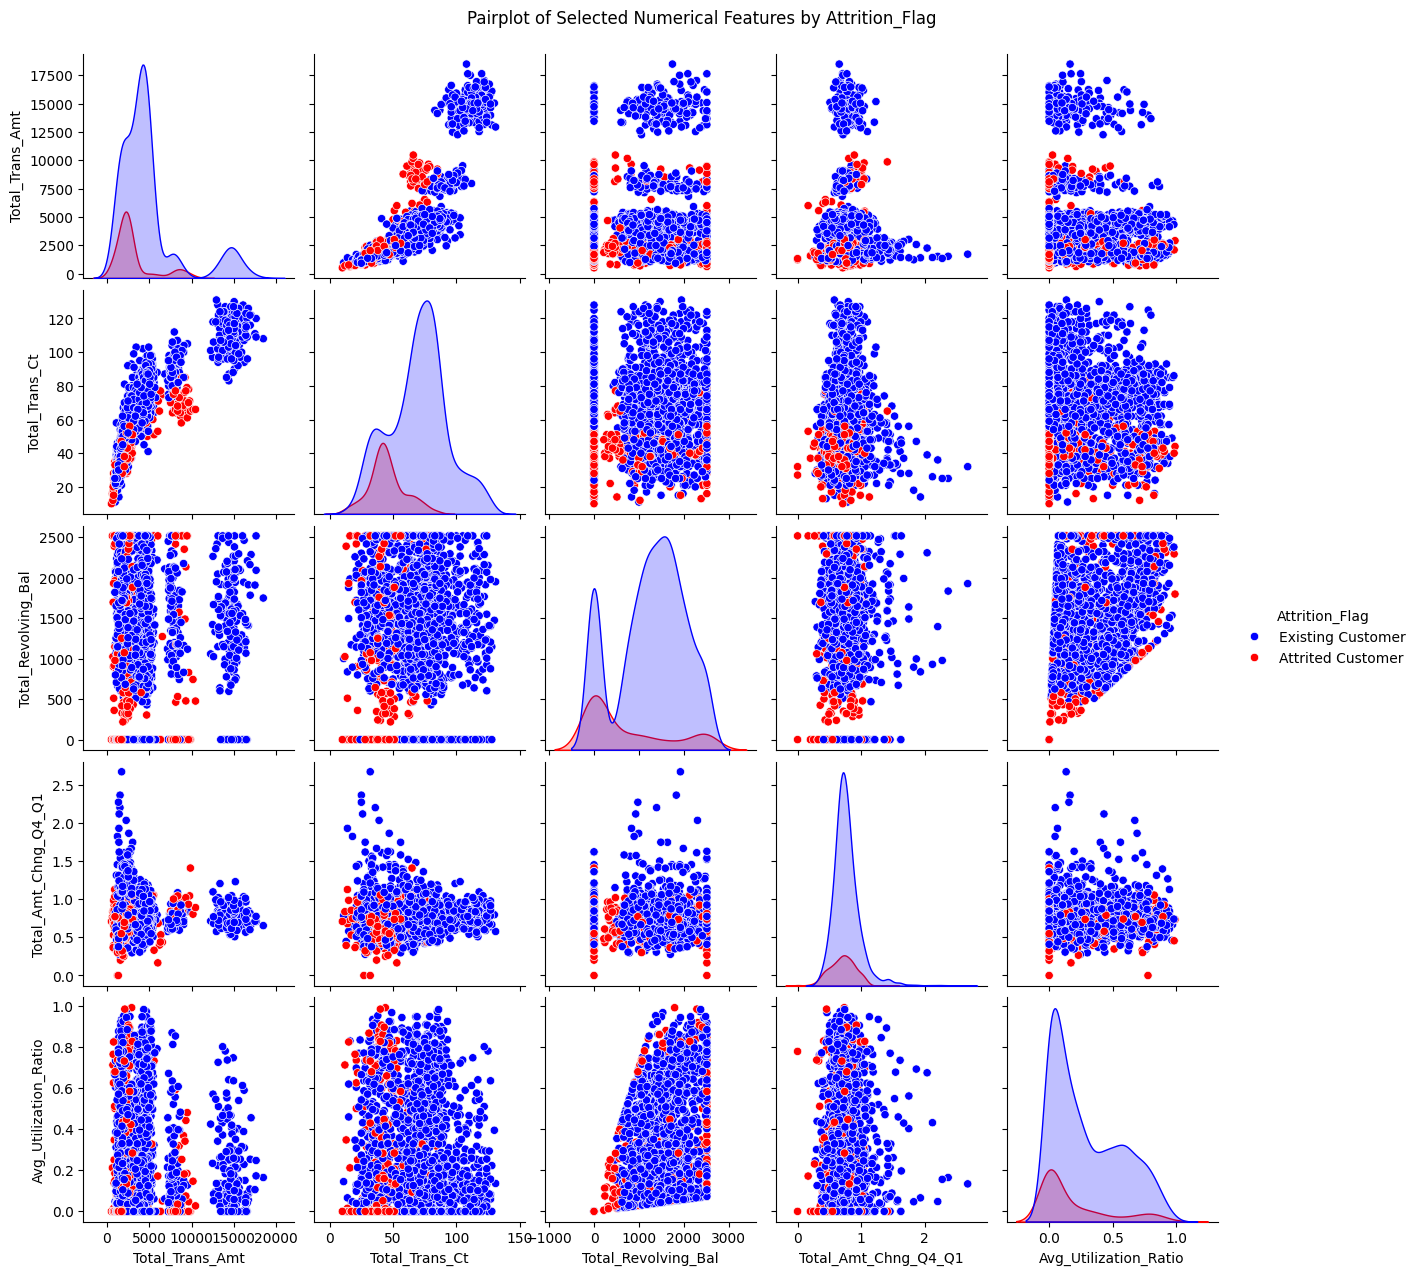

In [184]:
analysis_col =['Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
sns.pairplot(df.sample(frac=0.2), vars=analysis_col, hue='Attrition_Flag', palette={'Existing Customer': 'blue', 'Attrited Customer': 'red'})
plt.suptitle('Pairplot of Selected Numerical Features by Attrition_Flag', y=1.02)
plt.show()

# Feature Engineering

In [185]:
#copying the original dataset
df_original = df.copy()
df_original.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [186]:
# Engineered features

df['avg_amt_per_txn'] = df['Total_Trans_Amt'] / df['Total_Trans_Ct']
df['engagement_score'] = df['Total_Trans_Ct'] * df['Avg_Utilization_Ratio']
df['spend_change_intensity'] = df['Total_Trans_Amt'] * df['Total_Amt_Chng_Q4_Q1']

In [187]:
# converting target variable to binary
df['Attrition_Flag'] = df['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

In [188]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,avg_amt_per_txn,engagement_score,spend_change_intensity
0,768805383,0,45,M,3,High School,Married,$60K - $80K,Blue,39,...,777,11914.0,1.335,1144,42,1.625,0.061,27.238095,2.562,1527.240
1,818770008,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,864,7392.0,1.541,1291,33,3.714,0.105,39.121212,3.465,1989.431
2,713982108,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,0,3418.0,2.594,1887,20,2.333,0.000,94.350000,0.000,4894.878
3,769911858,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,2517,796.0,1.405,1171,20,2.333,0.760,58.550000,15.200,1645.255
4,709106358,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,0,4716.0,2.175,816,28,2.500,0.000,29.142857,0.000,1774.800


<Axes: >

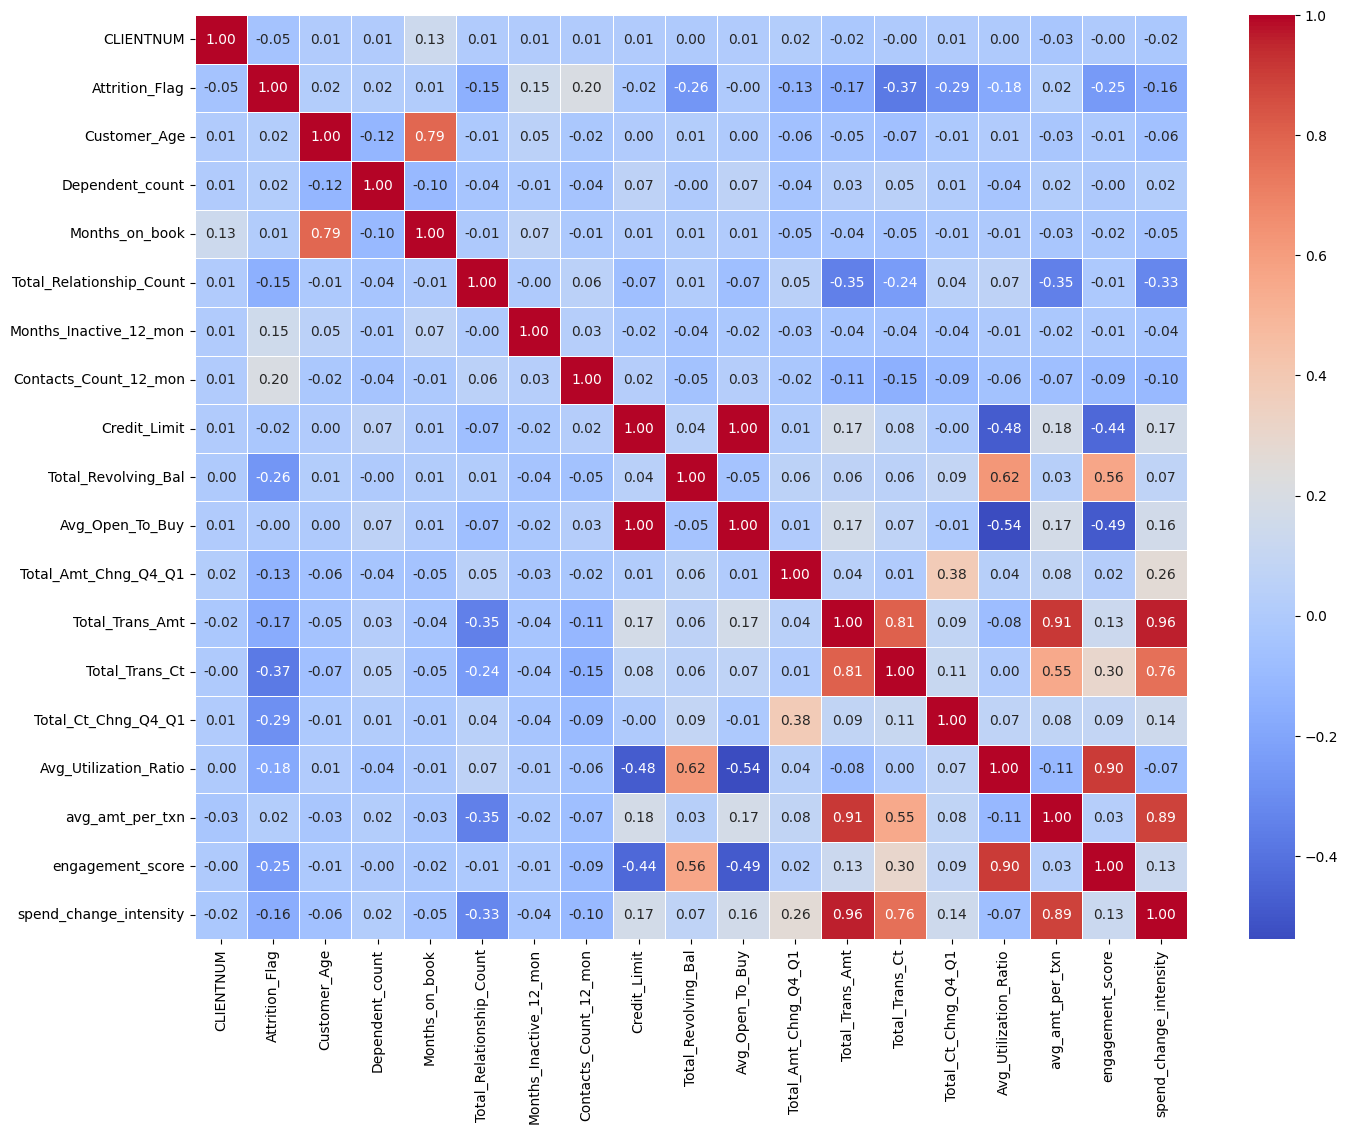

In [189]:
import seaborn as sns
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm',annot=True, fmt=".2f", linewidths=0.5)

In [98]:
df.corr(numeric_only=True)

,CLIENTNUM,Attrition_Flag,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,avg_amt_per_txn,engagement_score,spend_change_intensity
CLIENTNUM,1.000000,-0.046430,0.007613,0.006772,0.134588,0.006907,0.005729,0.005694,0.005708,0.000825,0.005633,0.017369,-0.019692,-0.002961,0.007696,0.000266,-0.031434,-0.000235,-0.017914
Attrition_Flag,-0.046430,1.000000,0.018203,0.018991,0.013687,-0.150005,0.152449,0.204491,-0.023873,-0.263053,-0.000285,-0.131063,-0.168598,-0.371403,-0.290054,-0.178410,0.016246,-0.245027,-0.161962
Customer_Age,0.007613,0.018203,1.000000,-0.122254,0.788912,-0.010931,0.054361,-0.018452,0.002476,0.014780,0.001151,-0.062042,-0.046446,-0.067097,-0.012143,0.007114,-0.029877,-0.012757,-0.058910
Dependent_count,0.006772,0.018991,-0.122254,1.000000,-0.103062,-0.039076,-0.010768,-0.040505,0.068065,-0.002688,0.068291,-0.035439,0.025046,0.049912,0.011087,-0.037135,0.018707,-0.004536,0.015829
Months_on_book,0.134588,0.013687,0.788912,-0.103062,1.000000,-0.009203,0.074164,-0.010774,0.007507,0.008623,0.006732,-0.048959,-0.038591,-0.049819,-0.014072,-0.007541,-0.029198,-0.021382,-0.048238
Total_Relationship_Count,0.006907,-0.150005,-0.010931,-0.039076,-0.009203,1.000000,-0.003675,0.055203,-0.071386,0.013726,-0.072601,0.050119,-0.347229,-0.241891,0.040831,0.067663,-0.346583,-0.012300,-0.325461
Months_Inactive_12_mon,0.005729,0.152449,0.054361,-0.010768,0.074164,-0.003675,1.000000,0.029493,-0.020394,-0.042210,-0.016605,-0.032247,-0.036982,-0.042787,-0.038989,-0.007503,-0.016782,-0.011025,-0.036050
Contacts_Count_12_mon,0.005694,0.204491,-0.018452,-0.040505,-0.010774,0.055203,0.029493,1.000000,0.020817,-0.053913,0.025646,-0.024445,-0.112774,-0.152213,-0.094997,-0.055471,-0.073186,-0.094797,-0.102686
Credit_Limit,0.005708,-0.023873,0.002476,0.068065,0.007507,-0.071386,-0.020394,0.020817,1.000000,0.042493,0.995981,0.012813,0.171730,0.075927,-0.002020,-0.482965,0.175635,-0.440114,0.167791
Total_Revolving_Bal,0.000825,-0.263053,0.014780,-0.002688,0.008623,0.013726,-0.042210,-0.053913,0.042493,1.000000,-0.047167,0.058174,0.064370,0.056060,0.089861,0.624022,0.033255,0.561203,0.070549


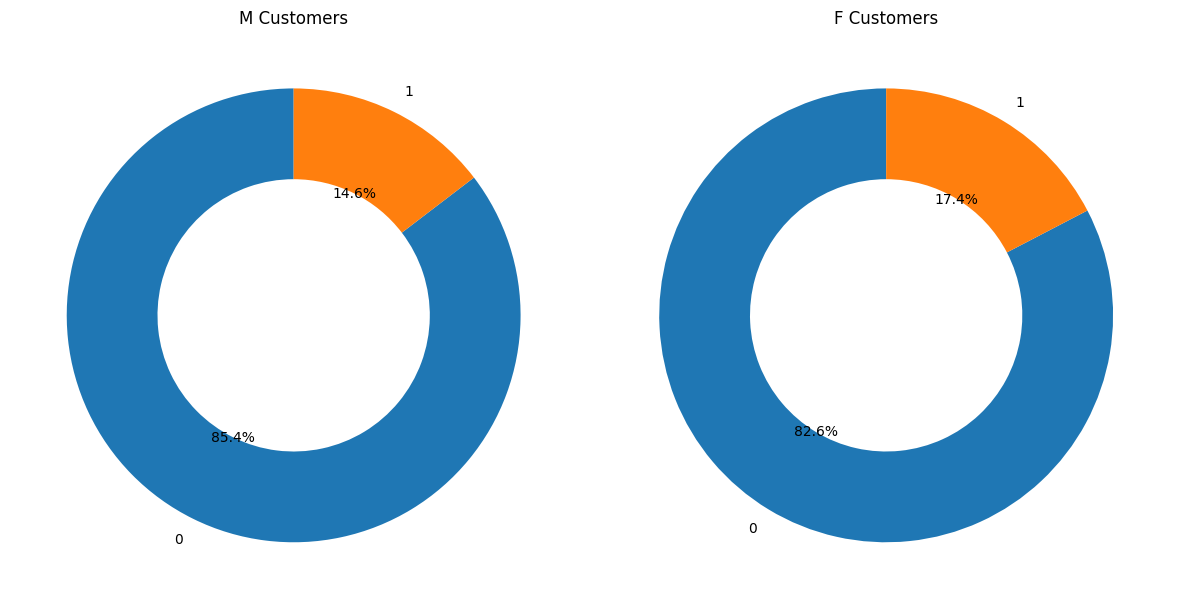

In [99]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

genders = ['M', 'F']

for i, gender in enumerate(genders):
    subset = df[df['Gender'] == gender]
    counts = subset['Attrition_Flag'].value_counts()
    
    axes[i].pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.4}
    )
    
    axes[i].set_title(f"{gender} Customers")

plt.tight_layout()
plt.show()

In [100]:
categorical = df.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical)

Categorical columns: Index(['Gender', 'Education_Level', 'Marital_Status', 'Income_Category',
       'Card_Category'],
      dtype='object')


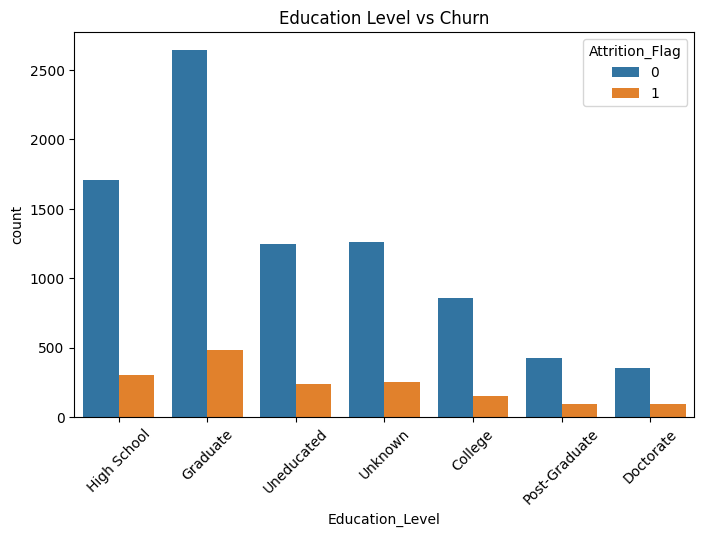

In [191]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Education_Level', hue='Attrition_Flag')
plt.xticks(rotation=45)
plt.title("Education Level vs Churn")
plt.show()

In [102]:
pd.crosstab(df['Education_Level'], df['Attrition_Flag'], normalize='index')

Attrition_Flag,0,1
Education_Level,,
College,0.847976,0.152024
Doctorate,0.789357,0.210643
Graduate,0.844309,0.155691
High School,0.847988,0.152012
Post-Graduate,0.821705,0.178295
Uneducated,0.840619,0.159381
Unknown,0.831468,0.168532


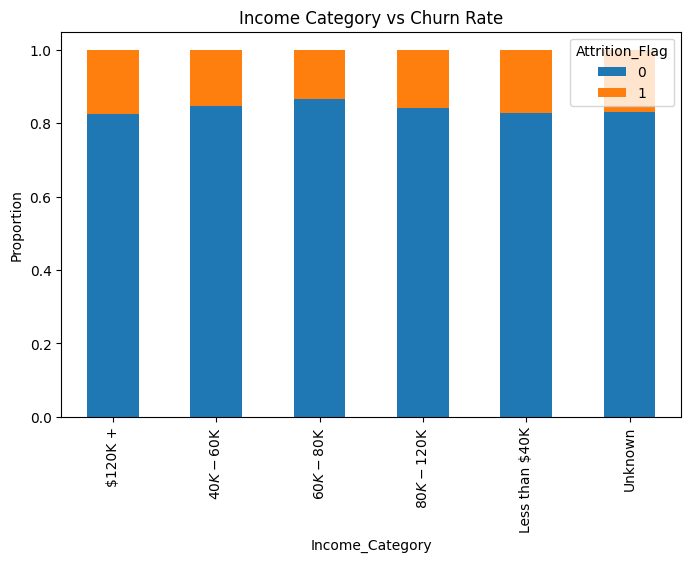

In [192]:
ct = pd.crosstab(df['Income_Category'], df['Attrition_Flag'], normalize='index')

ct.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Income Category vs Churn Rate")
plt.ylabel("Proportion")
plt.show()

In [193]:
df = pd.get_dummies(df, columns=['Education_Level', 'Income_Category'], drop_first=True)

In [194]:
drop_cols = [
    'CLIENTNUM',      
    'spend_change_intensity',
    'avg_amt_per_txn',
    'Avg_Open_To_Buy'
]

df = df.drop(columns=drop_cols, errors='ignore')

In [195]:
df = pd.get_dummies(
    df,
    columns=['Gender', 'Marital_Status', 'Card_Category'],
    drop_first=True
)

In [196]:
df.head(10)


,Attrition_Flag,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,...,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Gender_M,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,0,45,3,39,5,1,3,12691.0,777,1.335,...,False,False,False,True,True,False,False,False,False,False
1,0,49,5,44,6,1,2,8256.0,864,1.541,...,False,True,False,False,False,True,False,False,False,False
2,0,51,3,36,4,1,0,3418.0,0,2.594,...,True,False,False,True,True,False,False,False,False,False
3,0,40,4,34,3,4,1,3313.0,2517,1.405,...,False,True,False,False,False,False,True,False,False,False
4,0,40,3,21,5,1,0,4716.0,0,2.175,...,False,False,False,True,True,False,False,False,False,False
5,0,44,2,36,3,1,2,4010.0,1247,1.376,...,False,False,False,True,True,False,False,False,False,False
6,0,51,4,46,6,1,3,34516.0,2264,1.975,...,False,False,False,True,True,False,False,True,False,False
7,0,32,0,27,2,2,2,29081.0,1396,2.204,...,False,False,False,True,False,False,True,False,False,True
8,0,37,3,36,5,2,0,22352.0,2517,3.355,...,False,False,False,True,False,True,False,False,False,False
9,0,48,2,36,6,3,3,11656.0,1677,1.524,...,True,False,False,True,False,True,False,False,False,False


In [108]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Attrition_Flag                  10127 non-null  int64  
 1   Customer_Age                    10127 non-null  int64  
 2   Dependent_count                 10127 non-null  int64  
 3   Months_on_book                  10127 non-null  int64  
 4   Total_Relationship_Count        10127 non-null  int64  
 5   Months_Inactive_12_mon          10127 non-null  int64  
 6   Contacts_Count_12_mon           10127 non-null  int64  
 7   Credit_Limit                    10127 non-null  float64
 8   Total_Revolving_Bal             10127 non-null  int64  
 9   Total_Amt_Chng_Q4_Q1            10127 non-null  float64
 10  Total_Trans_Amt                 10127 non-null  int64  
 11  Total_Trans_Ct                  10127 non-null  int64  
 12  Total_Ct_Chng_Q4_Q1             

In [109]:
df.columns

Index(['Attrition_Flag', 'Customer_Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct',
       'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'engagement_score',
       'Education_Level_Doctorate', 'Education_Level_Graduate',
       'Education_Level_High School', 'Education_Level_Post-Graduate',
       'Education_Level_Uneducated', 'Education_Level_Unknown',
       'Income_Category_$40K - $60K', 'Income_Category_$60K - $80K',
       'Income_Category_$80K - $120K', 'Income_Category_Less than $40K',
       'Income_Category_Unknown', 'Gender_M', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Unknown', 'Card_Category_Gold',
       'Card_Category_Platinum', 'Card_Category_Silver'],
      dtype='object')

In [199]:
df['engagement_score'].head(20)

0      2.562
1      3.465
2      0.000
3     15.200
4      0.000
5      7.464
6      2.046
7      1.728
8      2.712
9      4.608
10     9.114
11     4.524
12     0.000
13     6.435
14     8.091
15     6.210
16     2.106
17     1.995
18    23.640
19     1.680
Name: engagement_score, dtype: float64

In [110]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Attrition_Flag                  10127 non-null  int64  
 1   Customer_Age                    10127 non-null  int64  
 2   Dependent_count                 10127 non-null  int64  
 3   Months_on_book                  10127 non-null  int64  
 4   Total_Relationship_Count        10127 non-null  int64  
 5   Months_Inactive_12_mon          10127 non-null  int64  
 6   Contacts_Count_12_mon           10127 non-null  int64  
 7   Credit_Limit                    10127 non-null  float64
 8   Total_Revolving_Bal             10127 non-null  int64  
 9   Total_Amt_Chng_Q4_Q1            10127 non-null  float64
 10  Total_Trans_Amt                 10127 non-null  int64  
 11  Total_Trans_Ct                  10127 non-null  int64  
 12  Total_Ct_Chng_Q4_Q1             

In [112]:
drop_cols = [
    'Credit_Limit',          
    'Dependent_count',       
    
]

df = df.drop(columns=drop_cols, errors='ignore')

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Attrition_Flag                  10127 non-null  int64  
 1   Customer_Age                    10127 non-null  int64  
 2   Months_on_book                  10127 non-null  int64  
 3   Total_Relationship_Count        10127 non-null  int64  
 4   Months_Inactive_12_mon          10127 non-null  int64  
 5   Contacts_Count_12_mon           10127 non-null  int64  
 6   Total_Revolving_Bal             10127 non-null  int64  
 7   Total_Amt_Chng_Q4_Q1            10127 non-null  float64
 8   Total_Trans_Amt                 10127 non-null  int64  
 9   Total_Trans_Ct                  10127 non-null  int64  
 10  Total_Ct_Chng_Q4_Q1             10127 non-null  float64
 11  Avg_Utilization_Ratio           10127 non-null  float64
 12  engagement_score                

In [114]:
df.columns

Index(['Attrition_Flag', 'Customer_Age', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1',
       'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
       'Avg_Utilization_Ratio', 'engagement_score',
       'Education_Level_Doctorate', 'Education_Level_Graduate',
       'Education_Level_High School', 'Education_Level_Post-Graduate',
       'Education_Level_Uneducated', 'Education_Level_Unknown',
       'Income_Category_$40K - $60K', 'Income_Category_$60K - $80K',
       'Income_Category_$80K - $120K', 'Income_Category_Less than $40K',
       'Income_Category_Unknown', 'Gender_M', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Unknown', 'Card_Category_Gold',
       'Card_Category_Platinum', 'Card_Category_Silver'],
      dtype='object')

# Training Multiple Models

In [115]:
X = df.drop('Attrition_Flag', axis=1)
y = df['Attrition_Flag']

In [116]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [117]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC


scores_logistic = []
scores_rf = []
scores_svm = []
scores_gb = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
   
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    

    lr = LogisticRegression(max_iter=1000, class_weight='balanced')
    lr.fit(X_train_scaled, y_train)
    y_prob_lr = lr.predict_proba(X_val_scaled)[:, 1]
    scores_logistic.append(roc_auc_score(y_val, y_prob_lr))
    

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_prob_rf = rf.predict_proba(X_val)[:, 1]
    scores_rf.append(roc_auc_score(y_val, y_prob_rf))
    

    svm = SVC(probability=True, class_weight='balanced')
    svm.fit(X_train_scaled, y_train)
    y_prob_svm = svm.predict_proba(X_val_scaled)[:, 1]
    scores_svm.append(roc_auc_score(y_val, y_prob_svm))
    
  
    gb = GradientBoostingClassifier(random_state=42)
    gb.fit(X_train, y_train)
    y_prob_gb = gb.predict_proba(X_val)[:, 1]
    scores_gb.append(roc_auc_score(y_val, y_prob_gb))
    
    print(f"\nFold {fold} done")


print("\nLogistic AUC:", scores_logistic, "Mean:", np.mean(scores_logistic))
print("Random Forest AUC:", scores_rf, "Mean:", np.mean(scores_rf))
print("SVM AUC:", scores_svm, "Mean:", np.mean(scores_svm))
print("Gradient Boosting AUC:", scores_gb, "Mean:", np.mean(scores_gb))


Fold 1 done

Fold 2 done

Fold 3 done

Fold 4 done

Fold 5 done

Logistic AUC: [0.9186665463731506, 0.9310591844099603, 0.9219800904977374, 0.9269357466063348, 0.9254515837104073] Mean: 0.9248186303195179
Random Forest AUC: [0.9853455431252256, 0.9914624684229519, 0.9822199095022625, 0.985323076923077, 0.9887484162895928] Mean: 0.9866198828526219
SVM AUC: [0.9523123421147601, 0.9633507758931793, 0.9500877828054298, 0.9603873303167421, 0.9538443438914027] Mean: 0.9559965150043027
Gradient Boosting AUC: [0.9888217250090221, 0.9921779141104294, 0.9851855203619909, 0.98750407239819, 0.9929303167420815] Mean: 0.9893239097243429


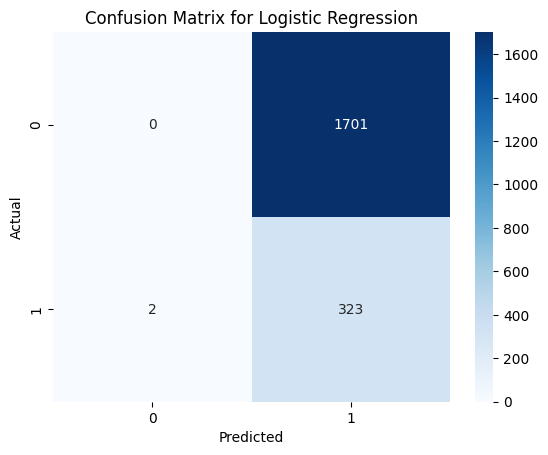

In [118]:
#confusion matrix for logistic regression
y_pred_lr = lr.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')   
plt.show()

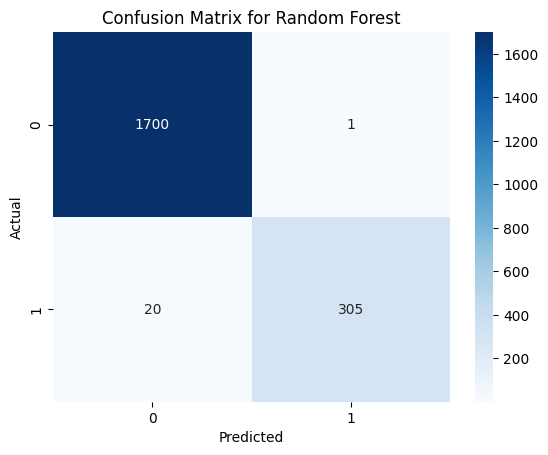

In [119]:
#confusion matrix for random forest
y_pred_rf = rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest')
plt.show()

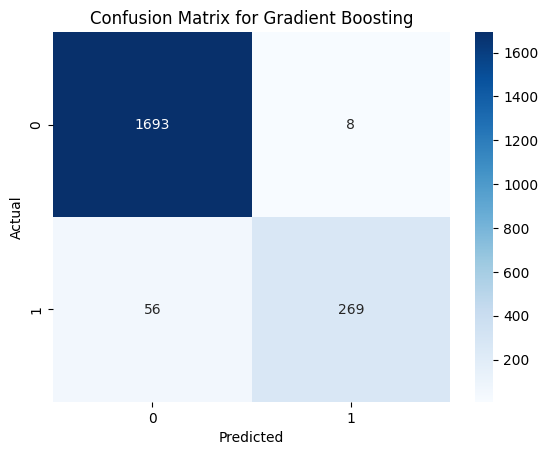

In [120]:
#confusion matrix for Gradient Boosting
y_pred_gb = gb.predict(X_test)
cm_gb = confusion_matrix(y_test, y_pred_gb) 
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Gradient Boosting')
plt.show()

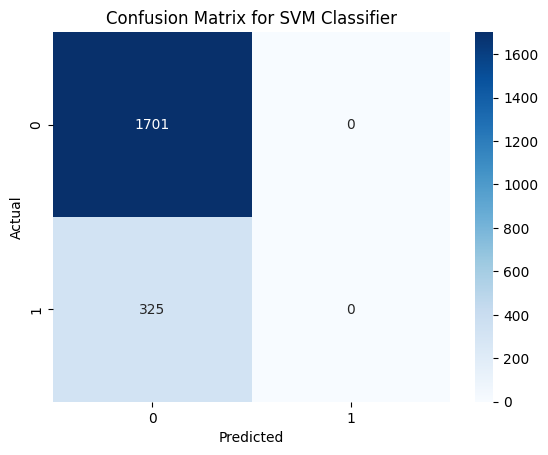

In [121]:
#confusion matrix for svm
y_pred_svm = svm.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)  
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()

In [122]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier
from catboost import CatBoostClassifier


scores_xgb = []
scores_cat = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
   
    xgb = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    )
    
    xgb.fit(X_train, y_train)
    y_prob_xgb = xgb.predict_proba(X_val)[:, 1]
    scores_xgb.append(roc_auc_score(y_val, y_prob_xgb))
    
   
    cat = CatBoostClassifier(
        iterations=200,
        learning_rate=0.05,
        depth=4,
        random_state=42,
        verbose=0
    )
    
    cat.fit(X_train, y_train)
    y_prob_cat = cat.predict_proba(X_val)[:, 1]
    scores_cat.append(roc_auc_score(y_val, y_prob_cat))
    
    print(f"\nFold {fold} done")


print("\nXGBoost AUC:", scores_xgb, "Mean:", np.mean(scores_xgb))
print("CatBoost AUC:", scores_cat, "Mean:", np.mean(scores_cat))


Fold 1 done

Fold 2 done

Fold 3 done

Fold 4 done

Fold 5 done

XGBoost AUC: [0.9911638397690364, 0.9944911584265608, 0.9897085972850679, 0.9915058823529412, 0.9950226244343892] Mean: 0.9923784204535991
CatBoost AUC: [0.9902020931071815, 0.9942186936124142, 0.9866660633484164, 0.9913556561085972, 0.9946660633484163] Mean: 0.9914217139050052


Confusion Matrix: XGBoost

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1701
           1       0.97      0.89      0.93       325

    accuracy                           0.98      2026
   macro avg       0.98      0.94      0.96      2026
weighted avg       0.98      0.98      0.98      2026



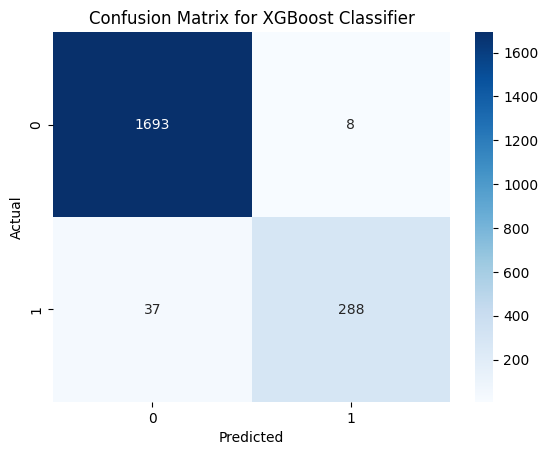

In [123]:
#confusion matrix and classification report for the best model (XGBoost)
y_pred_xgb = xgb.predict(X_test)
print("Confusion Matrix: XGBoost")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for XGBoost Classifier')
plt.show()

Confusion Matrix: CatBoost

Classification Report:


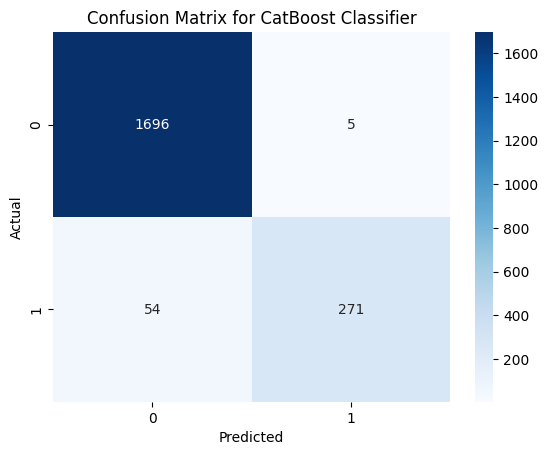

In [124]:
#Confusion matrix for CatBoost
y_pred_cat = cat.predict(X_test)
print("Confusion Matrix: CatBoost")
print("\nClassification Report:")
cm = confusion_matrix(y_test, y_pred_cat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for CatBoost Classifier')
plt.show()

# Using Hybrid model with Stacking Process

In [125]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier


In [126]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    class_weight='balanced',   
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight = (len(y) - sum(y)) / sum(y),  
    random_state=42,
    eval_metric='logloss'
)


In [127]:
stack_model = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('gb', gb),
        ('xgb', xgb)
    ],
    final_estimator= XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ),   
    stack_method='predict_proba',
    cv=5,
    n_jobs=-1,
    passthrough=True
    
)


In [128]:
scores_stack = []

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    stack_model.fit(X_train, y_train)
    
    y_prob = stack_model.predict_proba(X_val)[:, 1]
    
    auc = roc_auc_score(y_val, y_prob)
    scores_stack.append(auc)
    
    print(f"Fold {fold} AUC: {auc:.4f}")

Fold 1 AUC: 0.9930
Fold 2 AUC: 0.9898
Fold 3 AUC: 0.9947
Fold 4 AUC: 0.9950
Fold 5 AUC: 0.9896
Fold 6 AUC: 0.9928
Fold 7 AUC: 0.9922
Fold 8 AUC: 0.9915
Fold 9 AUC: 0.9933
Fold 10 AUC: 0.9963


In [129]:
print(np.mean(scores_stack))

0.992824919470174


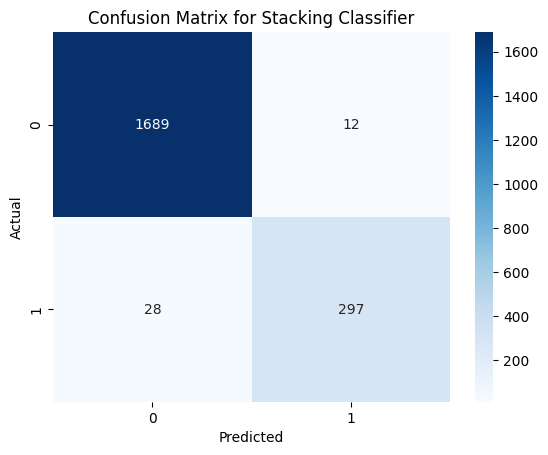

In [130]:
y_pred = stack_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Stacking Classifier')
plt.show()

In [131]:
#classification report for stacking model
print("Classification Report for Stacking Classifier:")
print(classification_report(y_test, y_pred))

Classification Report for Stacking Classifier:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1701
           1       0.96      0.91      0.94       325

    accuracy                           0.98      2026
   macro avg       0.97      0.95      0.96      2026
weighted avg       0.98      0.98      0.98      2026



In [132]:
models = {
    "Random Forest": scores_rf,
    "Gradient Boosting": scores_gb,
    "XGBoost": scores_xgb,
    "SVC": scores_svm,
    "Cat Boost": scores_cat,
    "Stacking": scores_stack
}
model_names = list(models.keys())
mean_scores = [np.mean(scores) for scores in models.values()]


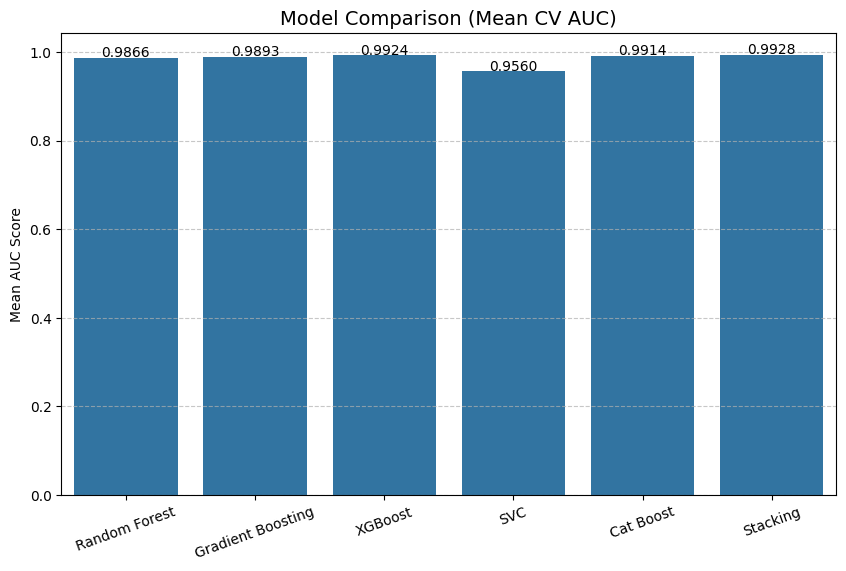

In [133]:
plt.figure(figsize=(10,6))
sns.barplot(x=model_names, y=mean_scores)

plt.title("Model Comparison (Mean CV AUC)", fontsize=14)
plt.ylabel("Mean AUC Score")
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top
for i, v in enumerate(mean_scores):
    plt.text(i, v + 0.002, f"{v:.4f}", ha='center')

plt.show()

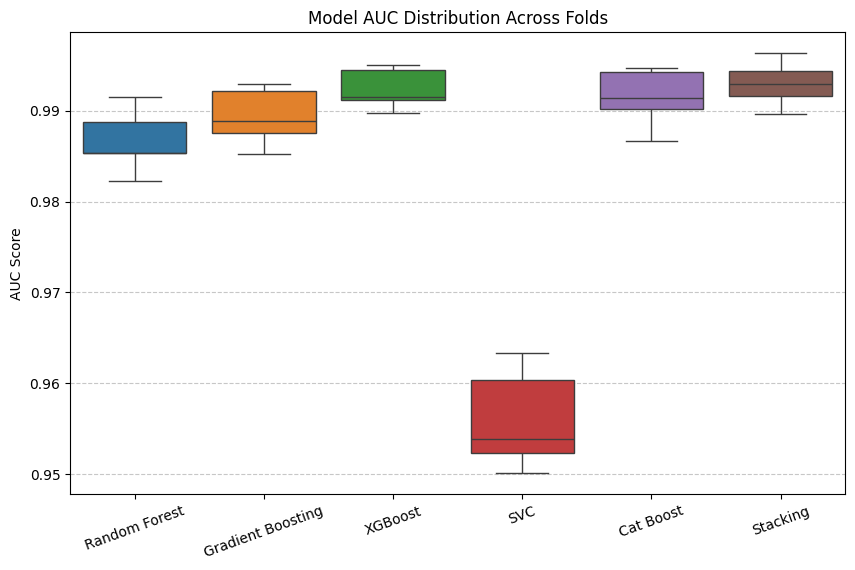

In [134]:
plt.figure(figsize=(10,6))
sns.boxplot(data=list(models.values()))

plt.xticks(ticks=range(len(model_names)), labels=model_names, rotation=20)
plt.title("Model AUC Distribution Across Folds")
plt.ylabel("AUC Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


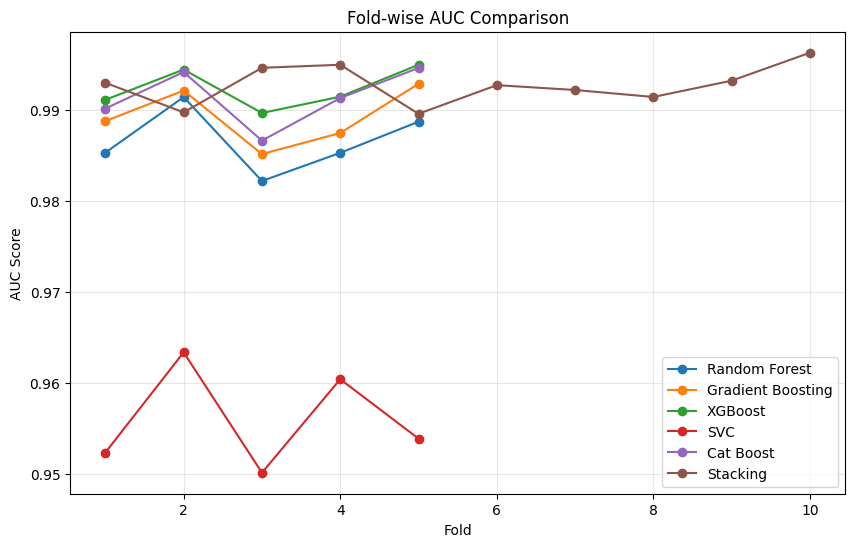

In [135]:
plt.figure(figsize=(10,6))

for name, scores in models.items():
    plt.plot(range(1, len(scores)+1), scores, marker='o', label=name)

plt.title("Fold-wise AUC Comparison")
plt.xlabel("Fold")
plt.ylabel("AUC Score")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

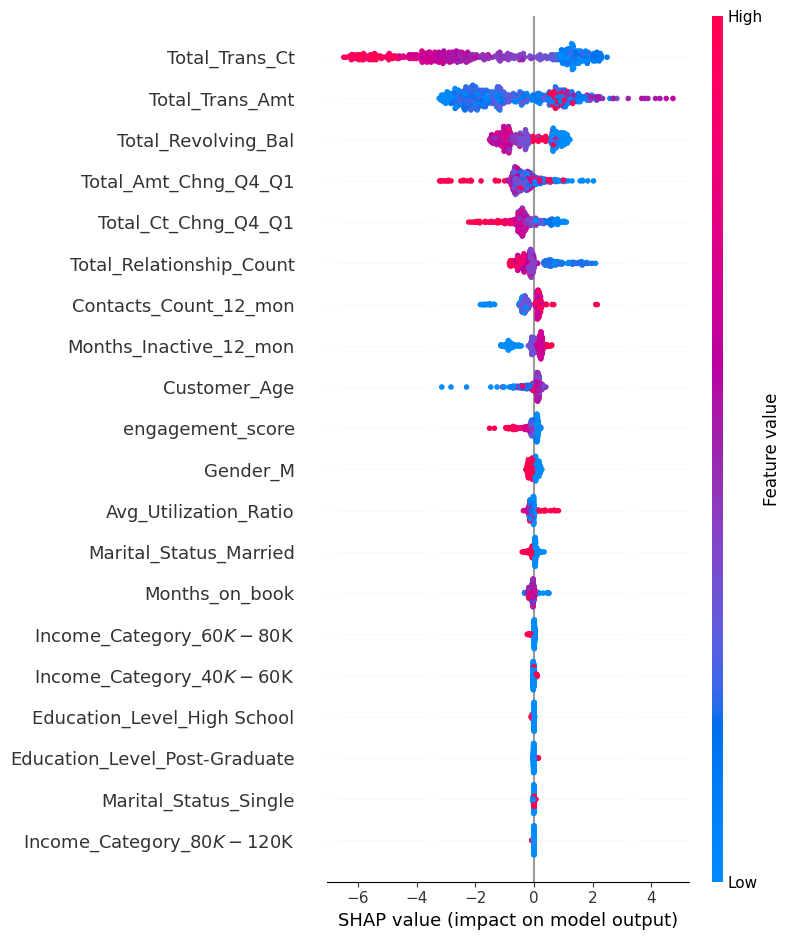

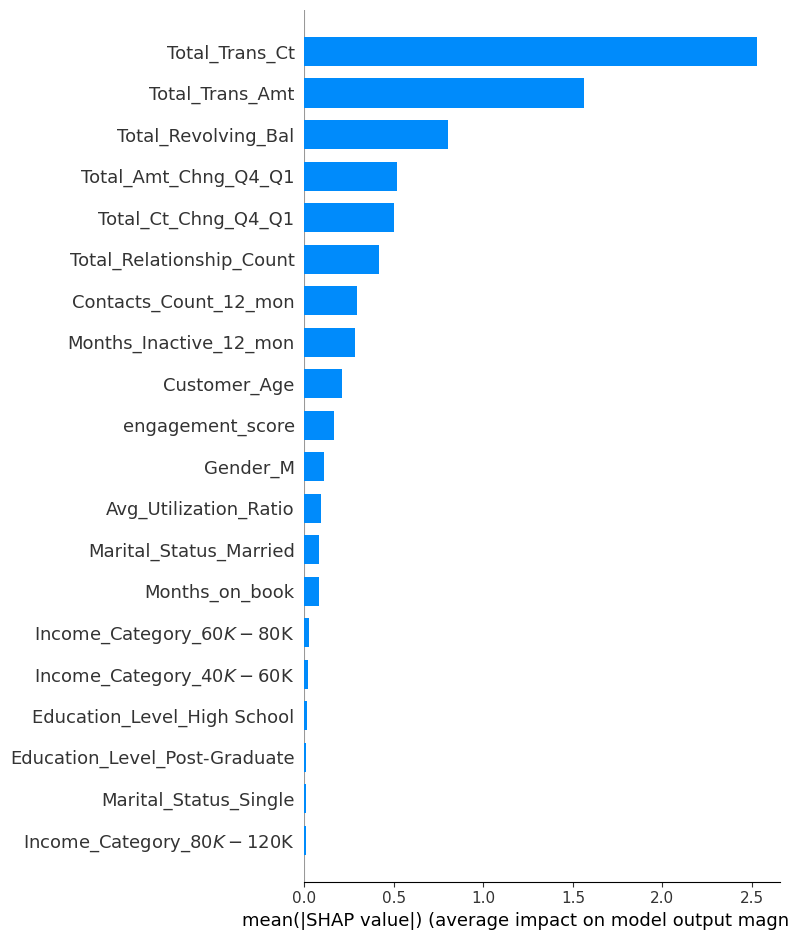

In [136]:
import shap
xgb_model = stack_model.named_estimators_['xgb']
X_sample = X_train.sample(500, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, X_sample)
shap.summary_plot(shap_values, X_sample, plot_type="bar")

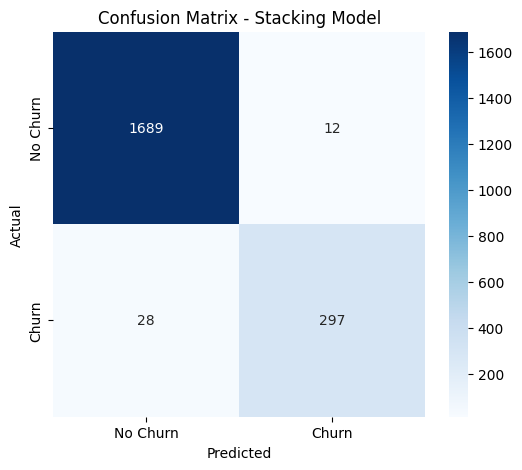

In [137]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


y_pred = stack_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Stacking Model")

plt.show()

In [138]:
print(stack_model)

StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=8,
                                                       min_samples_split=5,
                                                       n_estimators=300,
                                                       random_state=42)),
                               ('gb',
                                GradientBoostingClassifier(learning_rate=0.05,
                                                           n_estimators=200,
                                                           random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              

In [139]:
import joblib

joblib.dump(stack_model, "stacking_model.pkl")

['stacking_model.pkl']

In [140]:
import json

with open("features.json", "w") as f:
    json.dump(list(X_train.columns), f)

# Different Kinds of testing

In [141]:
loaded_model = joblib.load("stacking_model.pkl")
loaded_model.predict(X_test[:100])

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [142]:
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1701
           1       0.97      0.89      0.93       325

    accuracy                           0.98      2026
   macro avg       0.98      0.94      0.96      2026
weighted avg       0.98      0.98      0.98      2026



In [143]:
X_manual_1 = [[
45, 36, 4, 1, 2,
1500, 1.2, 5000, 80, 1.3, 0.3,
0.85,  # engagement_score

# Education (Graduate)
0,1,0,0,0,0,

# Income ($60K-$80K)
0,1,0,0,0,

# Gender
1,

# Marital (Married)
1,0,0,

# Card (Silver)
0,0,1
]]

In [144]:
X_manual_2 = [[
50, 24, 2, 5, 5,
200, 0.7, 1200, 20, 0.8, 0.05,
0.2,

# Education (Uneducated)
0,0,0,0,1,0,

# Income (<40K)
0,0,0,1,0,

# Gender
0,

# Marital (Single)
0,1,0,

# Card (Blue → all 0 since not listed)
0,0,0
]]

In [145]:
X_manual_3 = [[
42, 30, 3, 3, 3,
800, 1.0, 3000, 50, 1.0, 0.2,
0.5,

# Education (High School)
0,0,1,0,0,0,

# Income ($40K-$60K)
1,0,0,0,0,

# Gender
1,

# Marital (Unknown)
0,0,1,

# Card (Silver)
0,0,1
]]

In [146]:
loaded_model.predict(X_manual_1)


array([0])

In [147]:

loaded_model.predict(X_manual_2)

array([1])

In [148]:
loaded_model.predict(X_manual_3)

array([0])

In [149]:
loaded_model.predict_proba(X_manual_3)

array([[0.78183234, 0.21816769]], dtype=float32)

In [150]:
X_hard_1 = [[
45, 36, 4, 5, 5,   # high inactivity + contacts (bad)
1500, 1.2, 6000, 90, 1.3, 0.4,  # strong usage (good)
0.8,

# Education (Graduate)
0,1,0,0,0,0,

# Income ($80K-$120K)
0,0,1,0,0,

# Gender
1,

# Marital (Married)
1,0,0,

# Card (Silver)
0,0,1
]]
X_hard_2 = [[
50, 48, 5, 6, 6,
200, 0.6, 1000, 15, 0.7, 0.05,
0.2,

# Education (Post-Graduate)
0,0,0,1,0,0,

# Income ($120K)
0,0,1,0,0,

# Gender
1,

# Marital (Married)
1,0,0,

# Card (Gold)
1,0,0
]]
X_hard_3 = [[
42, 36, 4, 3, 3,
1200, 0.5, 2500, 40, 0.5, 0.2,  # declining trends
0.4,

# Education (Graduate)
0,1,0,0,0,0,

# Income ($60K-$80K)
0,1,0,0,0,

# Gender
0,

# Marital (Single)
0,1,0,

# Card (Silver)
0,0,1
]]
X_hard_4 = [[
25, 6, 1, 0, 0,
20000, 2.0, 20000, 150, 2.0, 0.9,
1.0,

# Education (Unknown)
0,0,0,0,0,1,

# Income (Unknown)
0,0,0,0,1,

# Gender
1,

# Marital (Unknown)
0,0,1,

# Card (Platinum)
0,1,0
]]

In [151]:
loaded_model.predict(X_hard_1)


array([0])

In [152]:
loaded_model.predict(X_hard_2)

array([1])

In [153]:
loaded_model.predict(X_hard_3)

array([1])

In [154]:
loaded_model.predict(X_hard_4)

array([0])

In [155]:
import json

feature_cols = list(X_train.columns)

with open("features_order.json", "w") as f:
    json.dump(feature_cols, f)


In [156]:
print(list(X_train.columns))

['Customer_Age', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'engagement_score', 'Education_Level_Doctorate', 'Education_Level_Graduate', 'Education_Level_High School', 'Education_Level_Post-Graduate', 'Education_Level_Uneducated', 'Education_Level_Unknown', 'Income_Category_$40K - $60K', 'Income_Category_$60K - $80K', 'Income_Category_$80K - $120K', 'Income_Category_Less than $40K', 'Income_Category_Unknown', 'Gender_M', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Unknown', 'Card_Category_Gold', 'Card_Category_Platinum', 'Card_Category_Silver']


In [157]:
print(list(X_test.columns))

['Customer_Age', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'engagement_score', 'Education_Level_Doctorate', 'Education_Level_Graduate', 'Education_Level_High School', 'Education_Level_Post-Graduate', 'Education_Level_Uneducated', 'Education_Level_Unknown', 'Income_Category_$40K - $60K', 'Income_Category_$60K - $80K', 'Income_Category_$80K - $120K', 'Income_Category_Less than $40K', 'Income_Category_Unknown', 'Gender_M', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Unknown', 'Card_Category_Gold', 'Card_Category_Platinum', 'Card_Category_Silver']


In [170]:
import pandas as pd

df2 = pd.DataFrame(X_hard_1, columns=feature_cols)
print(df2.T.rename(columns={0: "Sample_1"}))

                                Sample_1
Customer_Age                        45.0
Months_on_book                      36.0
Total_Relationship_Count             4.0
Months_Inactive_12_mon               5.0
Contacts_Count_12_mon                5.0
Total_Revolving_Bal               1500.0
Total_Amt_Chng_Q4_Q1                 1.2
Total_Trans_Amt                   6000.0
Total_Trans_Ct                      90.0
Total_Ct_Chng_Q4_Q1                  1.3
Avg_Utilization_Ratio                0.4
engagement_score                     0.8
Education_Level_Doctorate            0.0
Education_Level_Graduate             1.0
Education_Level_High School          0.0
Education_Level_Post-Graduate        0.0
Education_Level_Uneducated           0.0
Education_Level_Unknown              0.0
Income_Category_$40K - $60K          0.0
Income_Category_$60K - $80K          0.0
Income_Category_$80K - $120K         1.0
Income_Category_Less than $40K       0.0
Income_Category_Unknown              0.0
Gender_M        

In [159]:
from sklearn.metrics import classification_report
print(classification_report(y_test, loaded_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1701
           1       0.96      0.91      0.94       325

    accuracy                           0.98      2026
   macro avg       0.97      0.95      0.96      2026
weighted avg       0.98      0.98      0.98      2026



In [160]:
print(loaded_model)

StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=8,
                                                       min_samples_split=5,
                                                       n_estimators=300,
                                                       random_state=42)),
                               ('gb',
                                GradientBoostingClassifier(learning_rate=0.05,
                                                           n_estimators=200,
                                                           random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              